# Leap Seconds

In [30]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

plt.rcParams['figure.dpi'] = 300

def seconds_to_hhmm(x, pos):
    total_minutes = round(x / 60)
    hours = total_minutes // 60
    minutes = total_minutes % 60
    return f"{hours:02d}h{minutes:02d}m"

def seconds_to_h(x, pos):
    hours = int(x // 3600)
    return f"{hours:d}h"

def seconds_to_mmss(x, pos):
    minutes = int(x // 60)
    seconds = int(x - minutes * 60)
    return f"{minutes:02d}m{seconds:02d}s"

Length of day increase rate in seconds/year

In [4]:
D = 1.7/1000 / 100  # 1.7 ms per century

In [5]:
D

1.7e-05

## Leap seconds in the future

In [6]:
def length_of_day_delta(year): return year*D

In [7]:
length_of_day_delta(100) * 365

0.6204999999999999

In [8]:
def t_of_day_shift(year):
    return length_of_day_delta(year) / 2 * year * 365

In [9]:
t_of_day_shift(8000)

198560.0

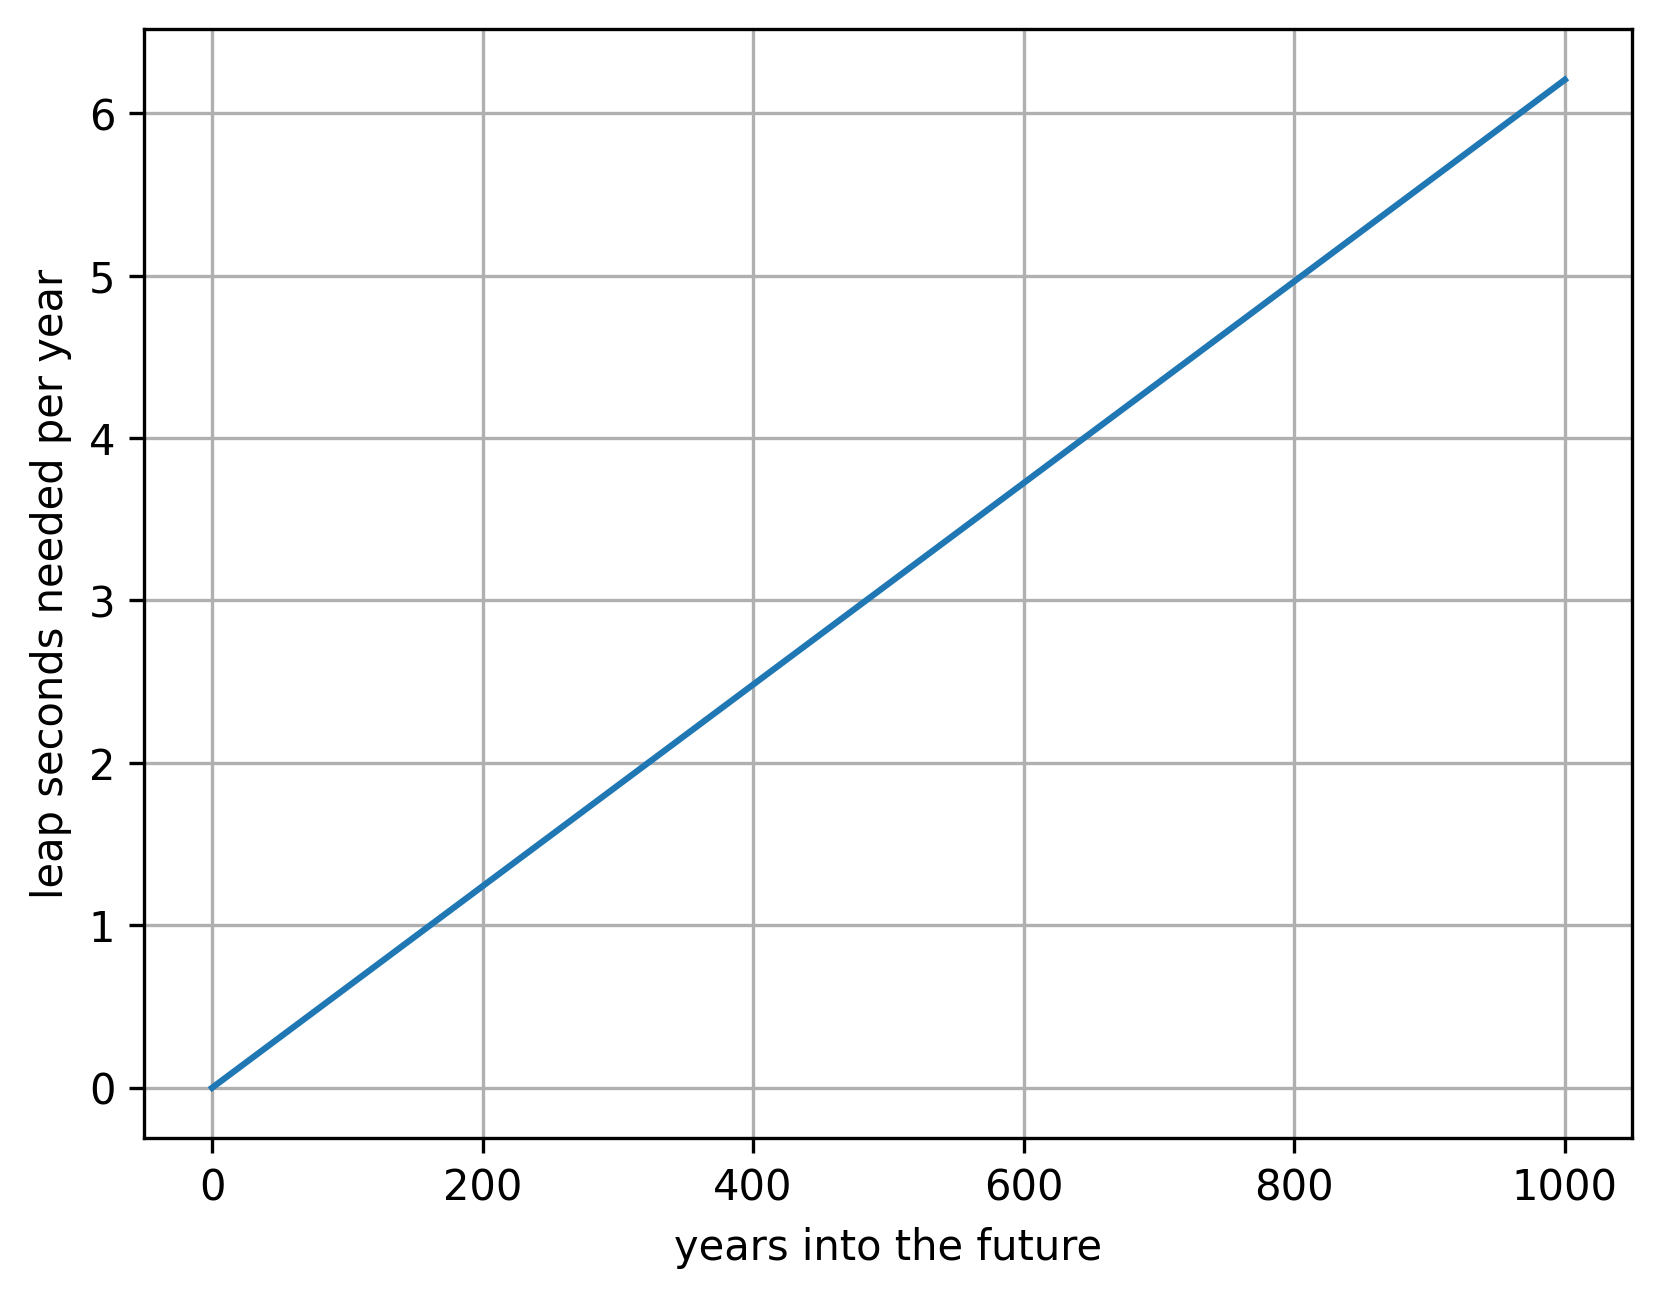

In [10]:
years = np.linspace(0,1000,100)
leapsec_per_year = length_of_day_delta(years) * 365
fig, ax = plt.subplots()
ax.plot(years, leapsec_per_year)
ax.set_xlabel("years into the future")
ax.set_ylabel("leap seconds needed per year")
ax.grid(True)

Text(0, 0.5, 'time of day deviation w/o leap seconds')

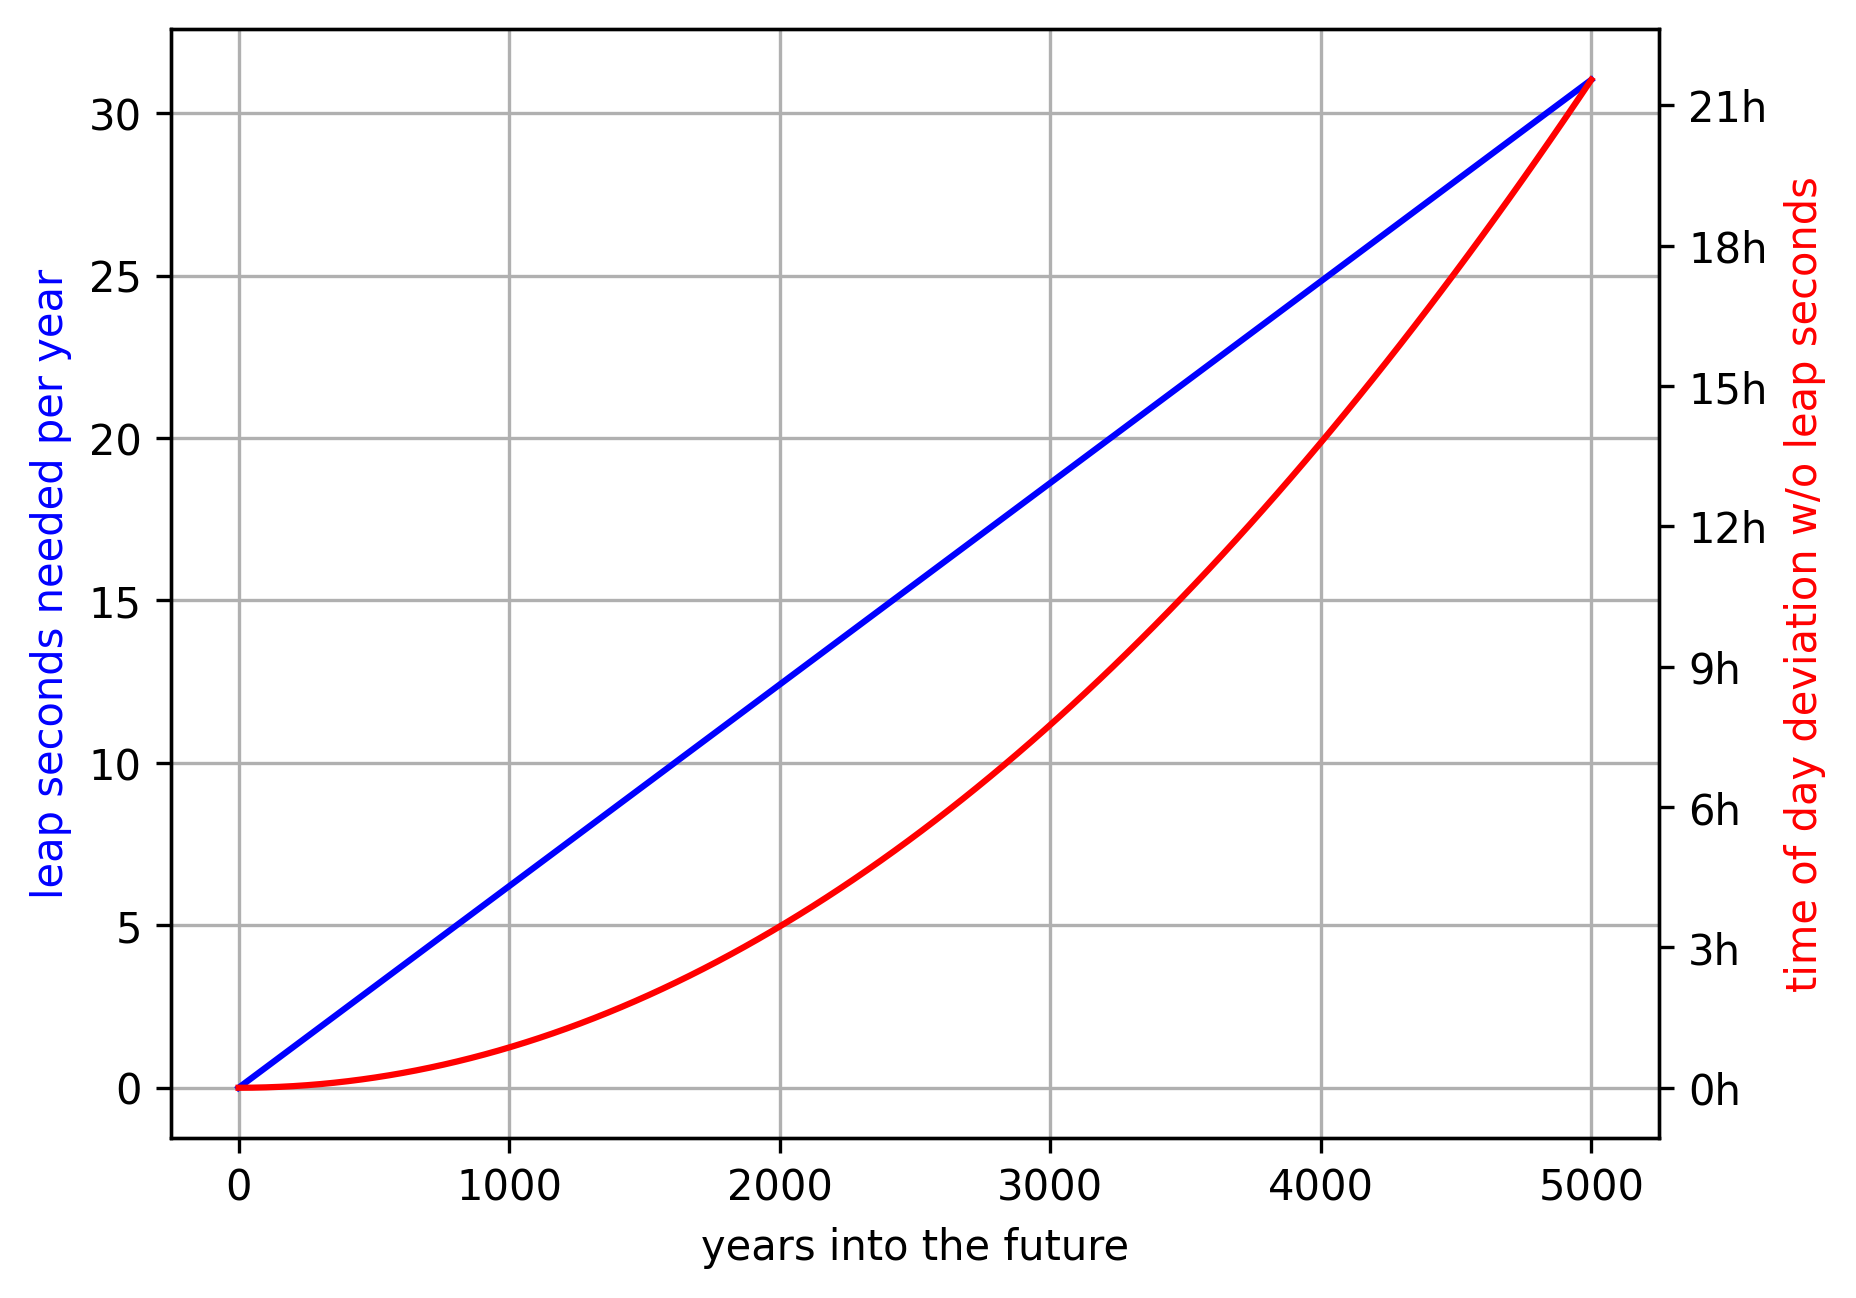

In [38]:
years = np.linspace(0,5000,100)
fig, ax = plt.subplots()
ax.plot(years, length_of_day_delta(years) * 365, 'b-')
ax.set_xlabel("years into the future")
ax.set_ylabel("leap seconds needed per year", color='b')
#ax.set_ylim(0, 7)
ax.grid(True)

ax2 = ax.twinx()
ax2.plot(years, t_of_day_shift(years), 'r-')
ax2.yaxis.set_major_formatter(FuncFormatter(seconds_to_h))
ax2.yaxis.set_major_locator(MultipleLocator(3*3600))
#ax2.set_ylim(0, 3600)
ax2.set_ylabel("time of day deviation w/o leap seconds", color='r')

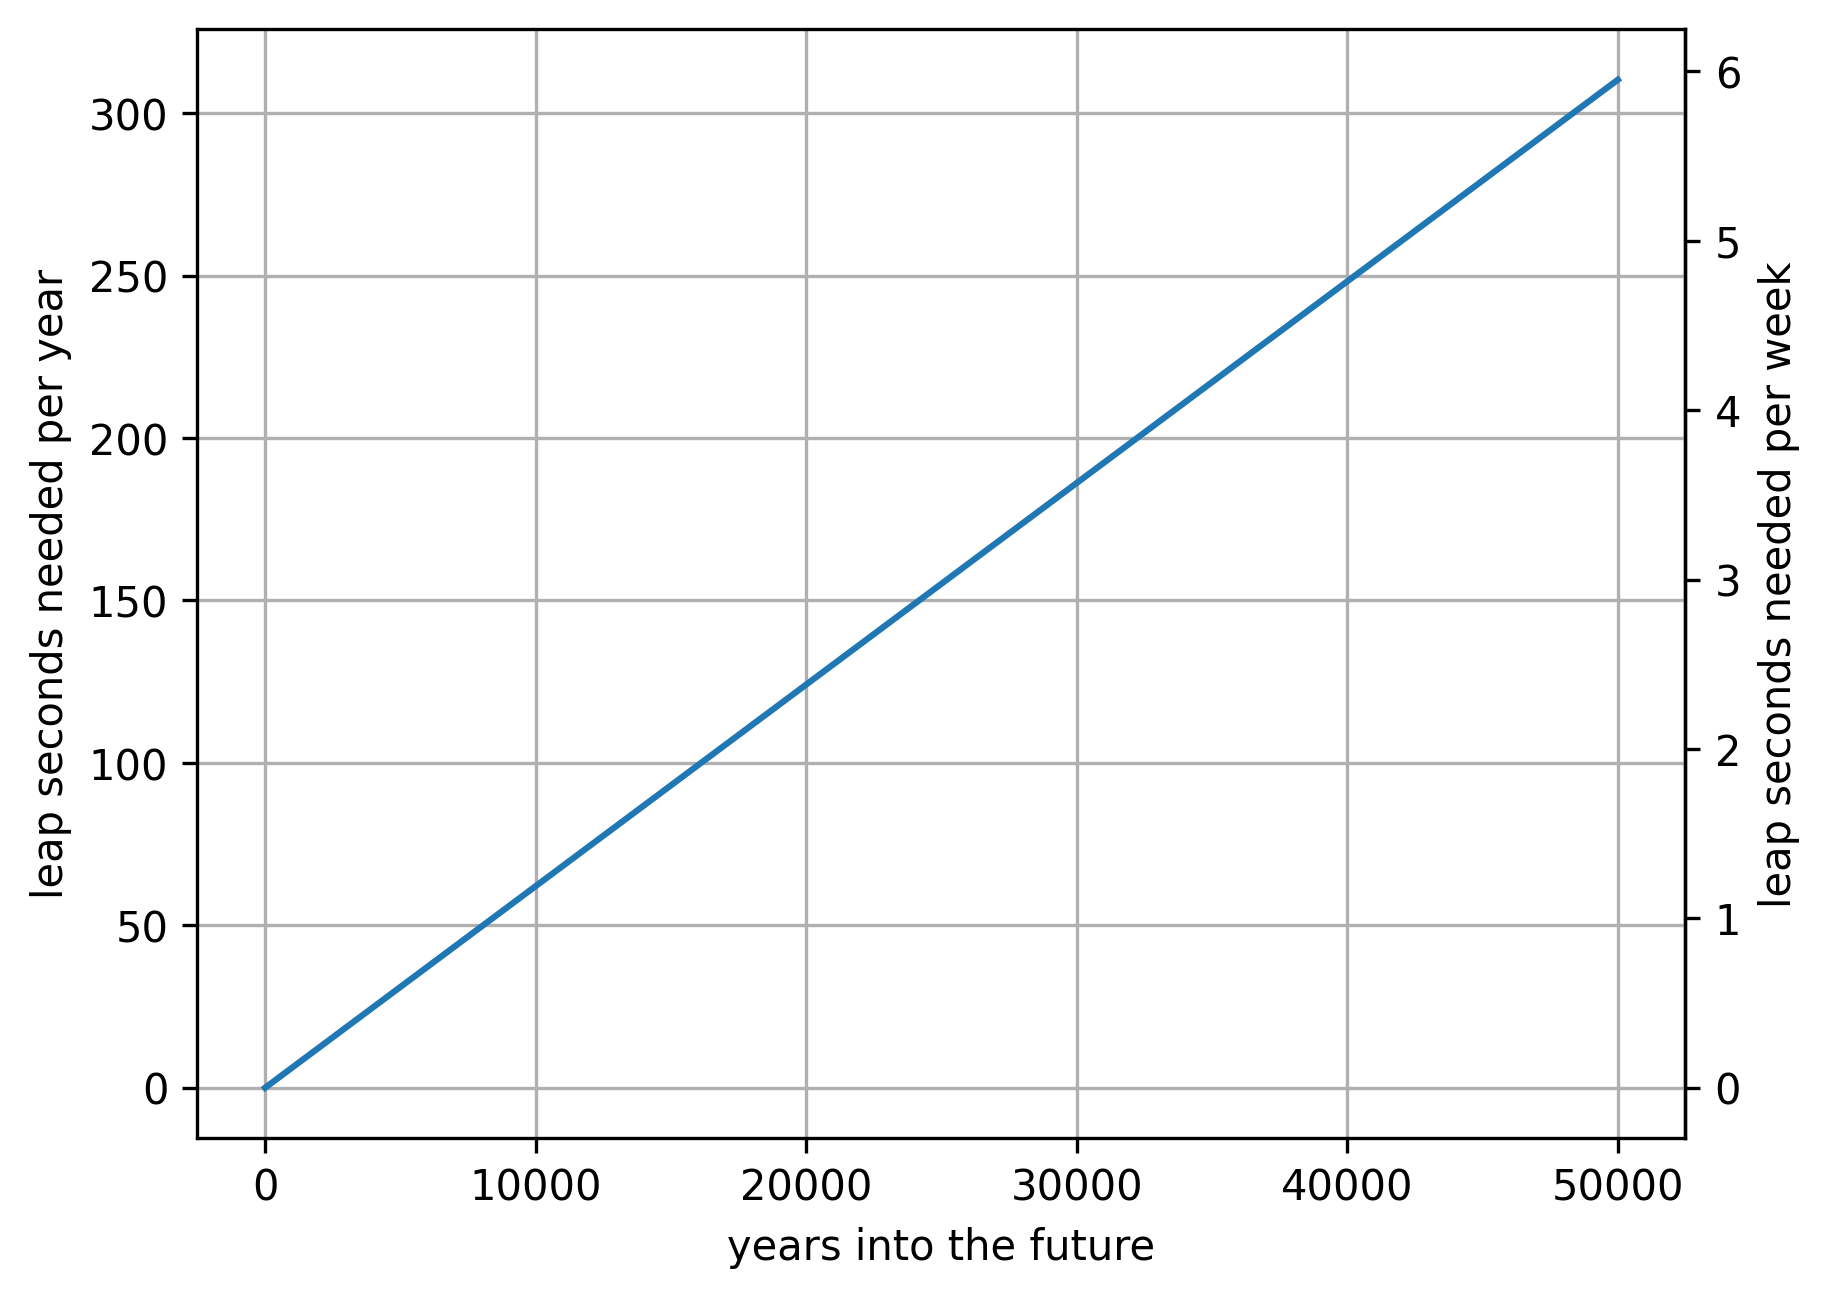

In [11]:
years = np.linspace(0,50000,100)
leapsec_per_year = length_of_day_delta(years) * 365
fig, ax = plt.subplots()
ax.plot(years, leapsec_per_year)
ax.set_xlabel("years into the future")
ax.set_ylabel("leap seconds needed per year")
ax.grid(True)
secax = ax.secondary_yaxis(location='right', functions=(lambda year: year*7/365, lambda week: week*365/7))
secax.set_ylabel('leap seconds needed per week')
secax.grid(True)

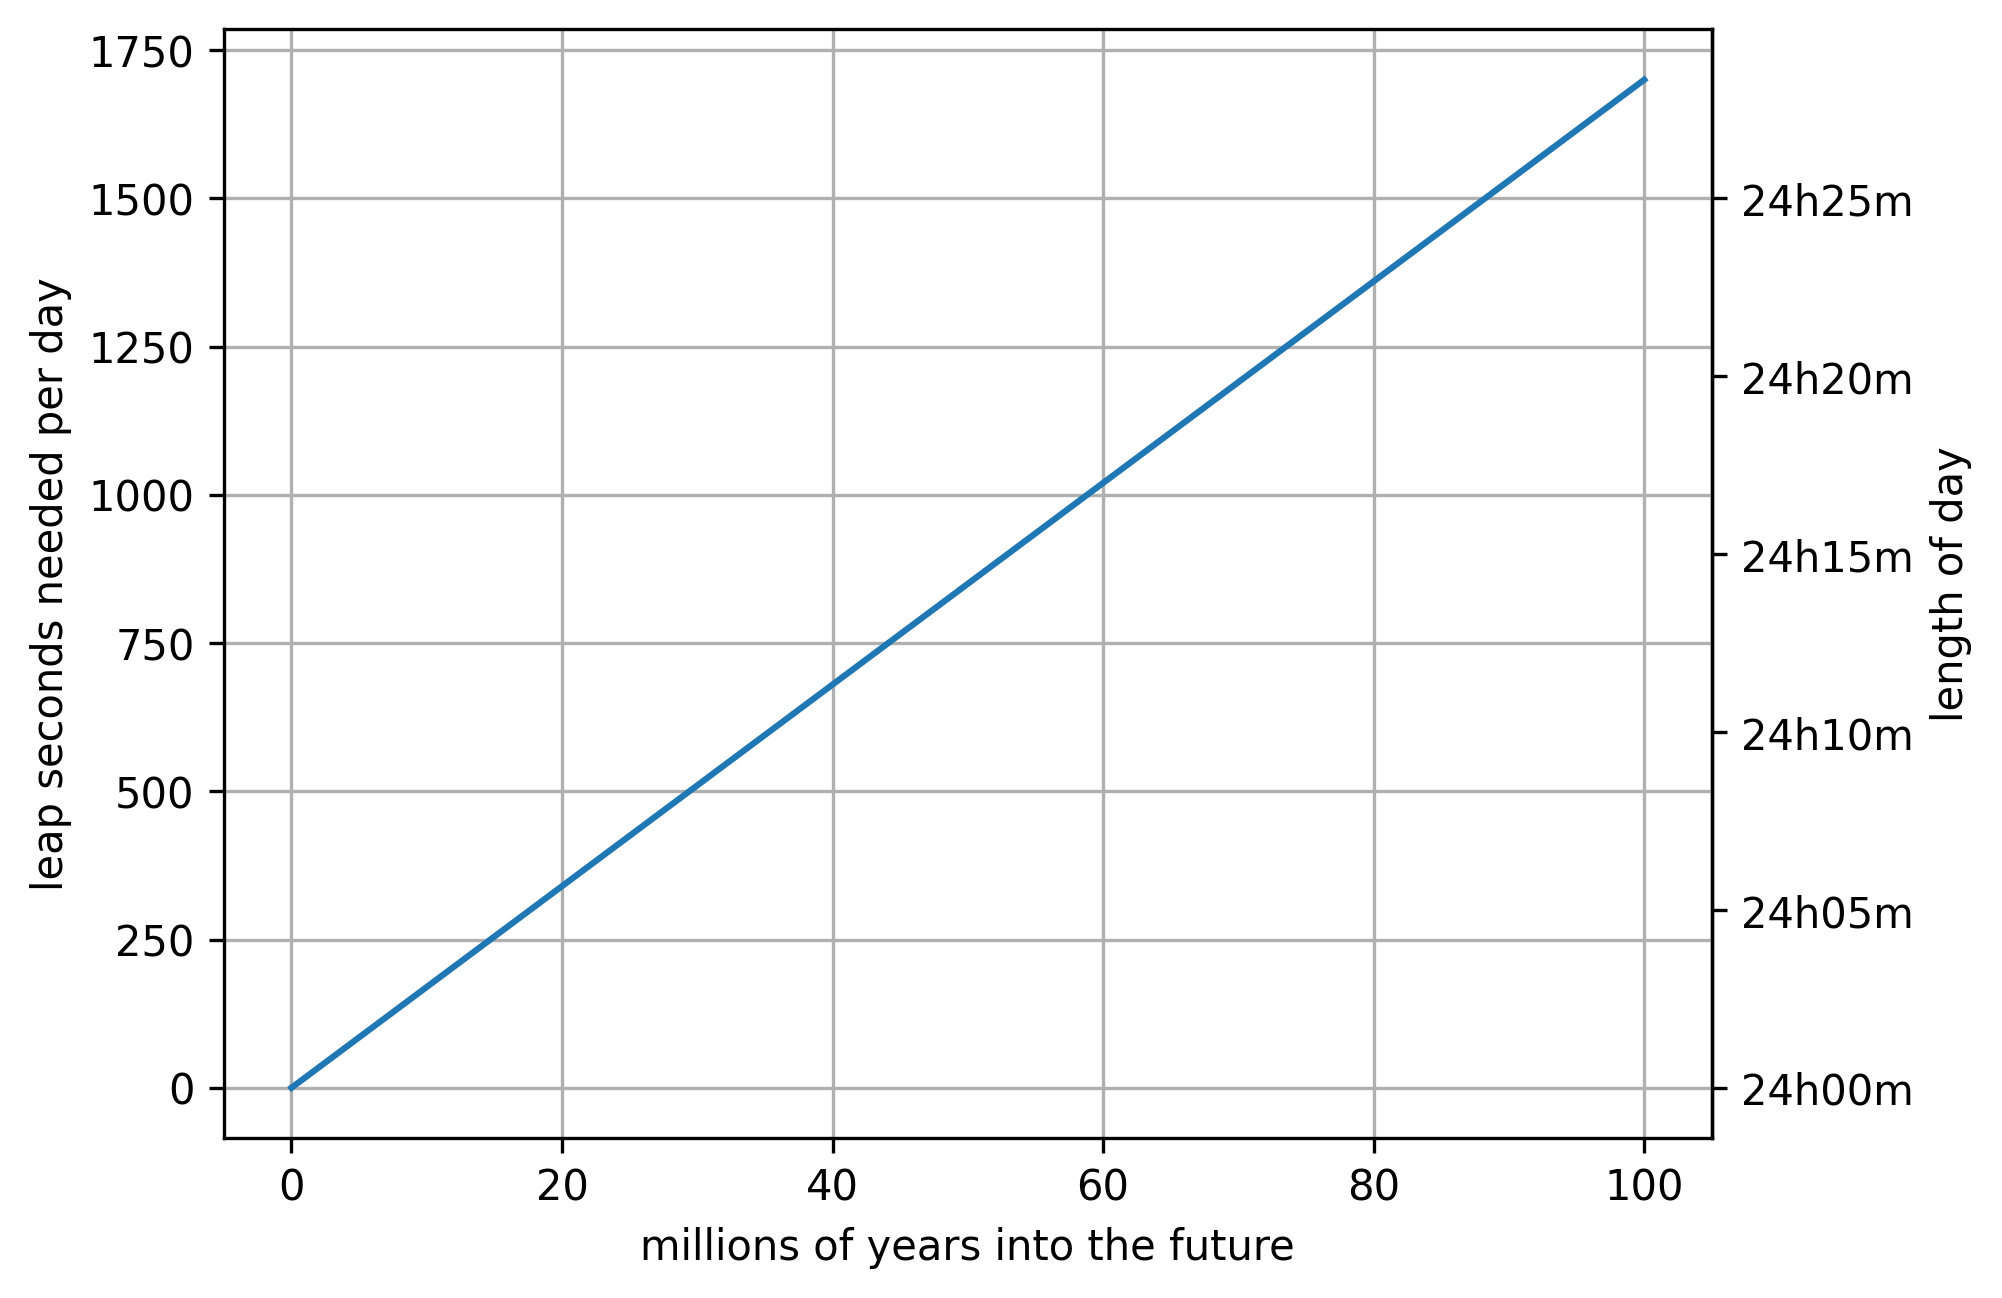

In [12]:
years = np.linspace(0,100e6,100)
leapsec_per_day = length_of_day_delta(years)
fig, ax = plt.subplots()
ax.plot(years/1e6, leapsec_per_day)
ax.set_xlabel("millions of years into the future")
ax.set_ylabel("leap seconds needed per day")
ax.grid(True)
secax = ax.secondary_yaxis(location='right', functions=(lambda lpd: lpd + 24*3600, lambda day: day - 24*3600))
secax.set_ylabel('length of day')
secax.yaxis.set_major_formatter(FuncFormatter(seconds_to_hhmm))
secax.yaxis.set_major_locator(MultipleLocator(300))
secax.grid(True)

## Time of day shift in the future

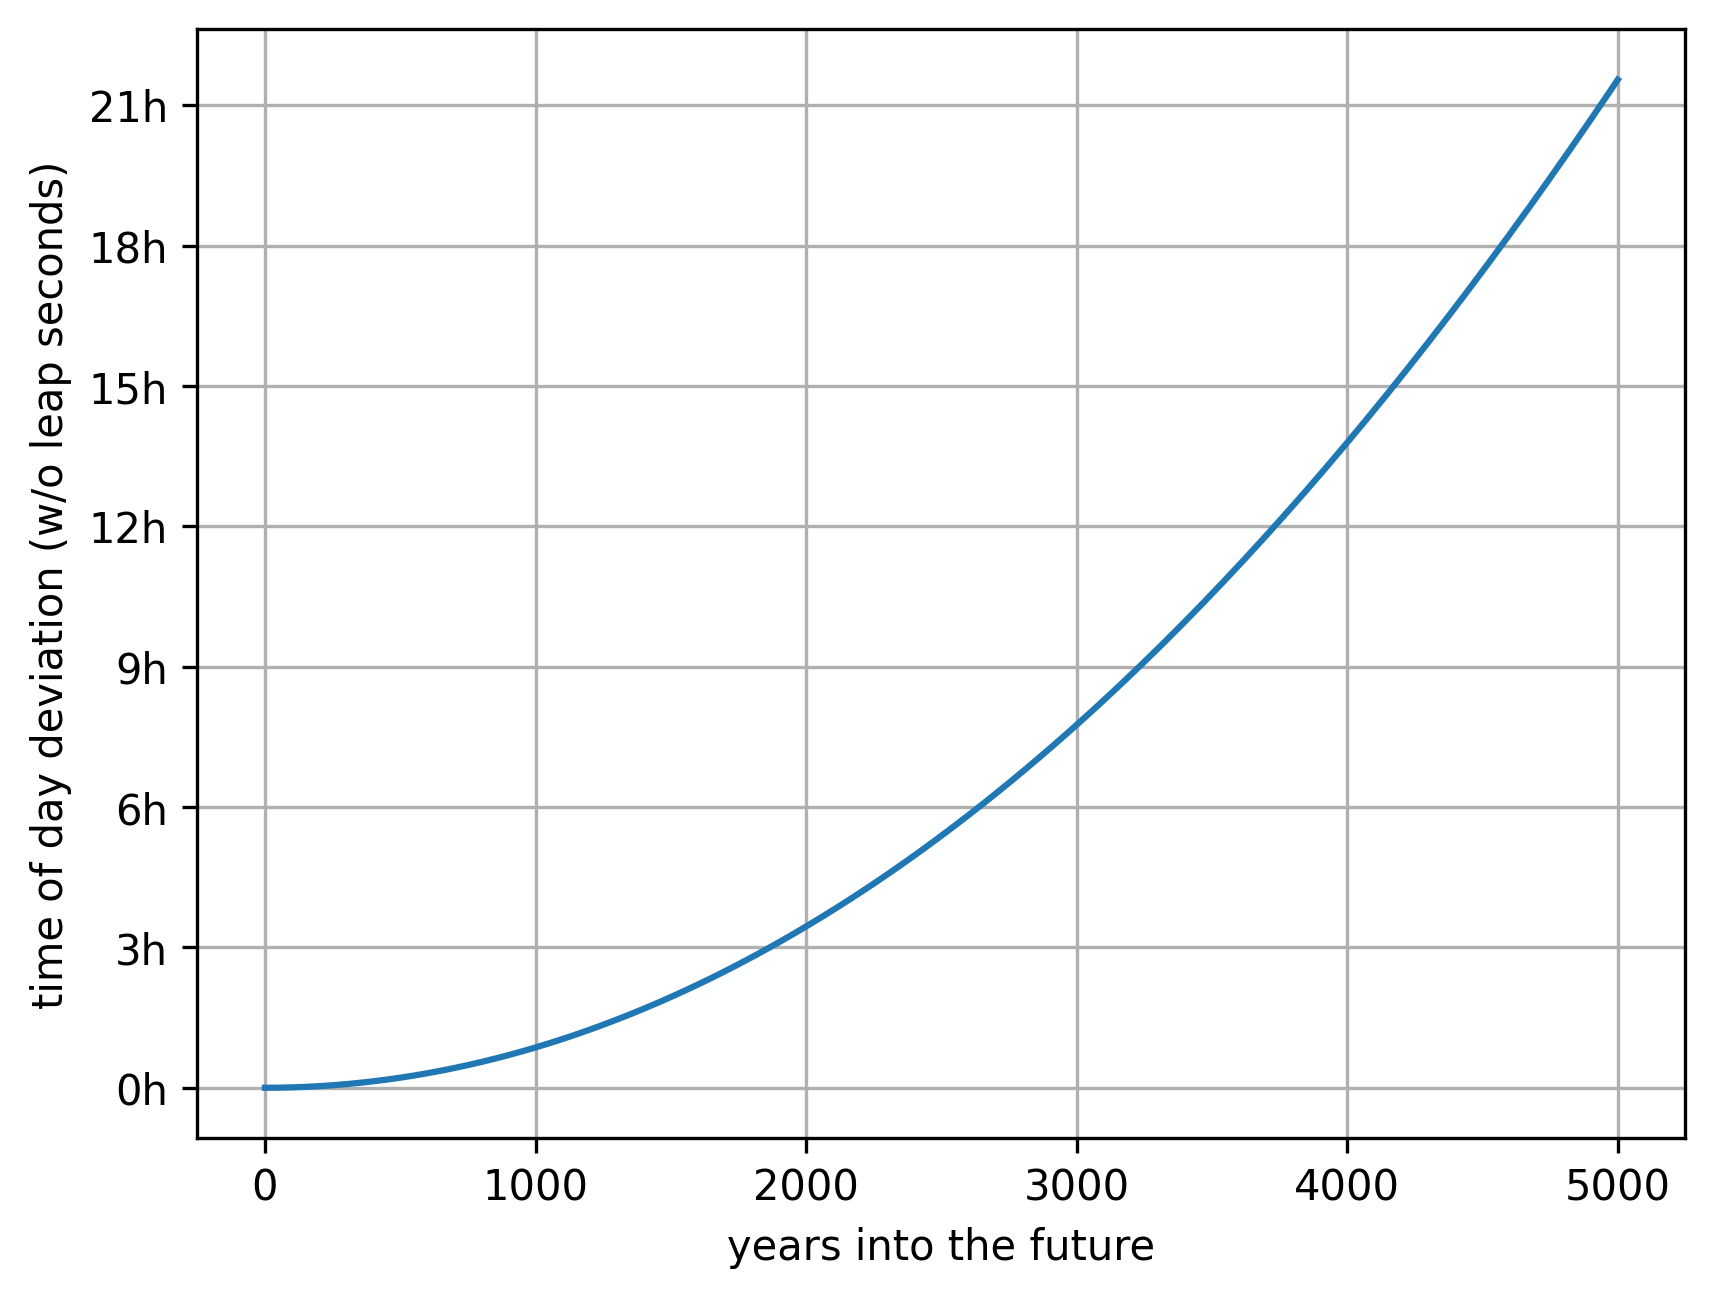

In [39]:
years = np.linspace(0,5000,200)
leapsec_per_day = length_of_day_delta(years)
fig, ax = plt.subplots()
ax.plot(years, t_of_day_shift(years))
ax.set_xlabel("years into the future")
ax.set_ylabel("time of day deviation (w/o leap seconds)")

ax.yaxis.set_major_formatter(FuncFormatter(seconds_to_h))
ax.yaxis.set_major_locator(MultipleLocator(3*3600))
ax.grid(True)